# Data cleaning

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/home/jawad/my_jupyter_env/Data_Science_Projects/Urban-Road-Safety-Near-Miss-Analysis/urban_near_miss_dataset_12000.csv")

In [4]:
df.head()

,Record_ID,City,Day_of_Week,Hour,Weather,Traffic_Level,Vehicle_Type,Road_Type,Speed_Limit_kmh,Average_Speed_kmh,Pedestrian_Count,Visibility_Percent,Near_Miss_Score,Incident
0,1,Peshawar,Thursday,6,Cloudy,Medium,Motorcycle,Main Road,60,51.7,11,82.3,40.2,0
1,2,Karachi,Friday,19,Clear,Medium,Bus,Residential,50,51.8,10,91.1,31.6,0
2,3,Rawalpindi,Friday,14,Clear,Medium,Rickshaw,Residential,50,74.7,11,82.2,44.8,0
3,4,Peshawar,Sunday,10,Rain,High,Car,Main Road,60,39.4,7,74.0,35.6,0
4,5,Rawalpindi,Saturday,7,Rain,Severe,Rickshaw,Highway,100,62.5,8,97.3,57.1,1


In [5]:
# null value in the data set 
print(df.isnull().sum())
print("*"*45)

# check duplicates rows in the data set 
print(df.duplicated().sum())
print("*"*45)

# checking the data types of the columns
print(df.dtypes)
print("*"*45)

# checking the hours in the correct formate or not 
print(df["Hour"].between(0,23).all())
print("*"*45)

print(df["Hour"].between(0,100).all())

Record_ID             0
City                  0
Day_of_Week           0
Hour                  0
Weather               0
Traffic_Level         0
Vehicle_Type          0
Road_Type             0
Speed_Limit_kmh       0
Average_Speed_kmh     0
Pedestrian_Count      0
Visibility_Percent    0
Near_Miss_Score       0
Incident              0
dtype: int64
*********************************************
0
*********************************************
Record_ID               int64
City                      str
Day_of_Week               str
Hour                    int64
Weather                   str
Traffic_Level             str
Vehicle_Type              str
Road_Type                 str
Speed_Limit_kmh         int64
Average_Speed_kmh     float64
Pedestrian_Count        int64
Visibility_Percent    float64
Near_Miss_Score       float64
Incident                int64
dtype: object
*********************************************
True
*********************************************
True


# Basic Analysis

In [6]:
# what is the average speed .
avg_speed = df["Average_Speed_kmh"].mean()
print("Average speed : ",avg_speed)

# median speed 
med_speed = df["Average_Speed_kmh"].median()
print("median speed : ",med_speed)

# highest speed
high_speed = df["Average_Speed_kmh"].max()
print("highest speed : ",high_speed)

# standard deviation of near miss score 
miss_score_std = df["Near_Miss_Score"].std()
print("Near miss score standard deviation : ",miss_score_std.round(3))

# what is the percentage obeservation had in incident.
total_observation = len(df)
print("total observation : ",total_observation)
incident_observation = df["Incident"].sum()
print("Incident observation : ",incident_observation)
percentage_of_incident_obser = (incident_observation / total_observation ) * 100
print("total percentage of the incident observation : ",percentage_of_incident_obser.round(3))



Average speed :  47.459875
median speed :  44.0
highest speed :  120.0
Near miss score standard deviation :  15.585
total observation :  12000
Incident observation :  2018
total percentage of the incident observation :  16.817


# City analysis

In [7]:
# how many observation from each city ?
ob_each_city = df["City"].value_counts()
print("observation of each city : ",ob_each_city)
print("*" * 50)


# which city has the most incident ?
incident = df.groupby("City")["Incident"].sum()
most_incident = incident.idxmax()
print("\nmost incident city : ",most_incident)
print("*" * 50)


# which city has the highest average  near miss score ?
miss_score = df.groupby("City")["Near_Miss_Score"].mean()
print("\nNear miss score : ",miss_score)
highest_avg_miss_score = miss_score.idxmax()
print("\nhighest average near miss score : ",highest_avg_miss_score )
print("*" * 50)

# which city has the lowest incident rate ?
incident_rate = df.groupby("City")["Incident"].mean() * 100
print("incident rate of all city : ",incident_rate)
print("*" * 50)

lowest_incident_Rate = incident_rate.idxmin()
print("lowest incident rate of the city : ",lowest_incident_Rate)





observation of each city :  City
Karachi       1779
Multan        1734
Rawalpindi    1732
Quetta        1704
Peshawar      1702
Islamabad     1692
Lahore        1657
Name: count, dtype: int64
**************************************************

most incident city :  Multan
**************************************************

Near miss score :  City
Islamabad     40.851537
Karachi       40.450422
Lahore        41.356488
Multan        40.992445
Peshawar      40.598472
Quetta        41.170599
Rawalpindi    40.850289
Name: Near_Miss_Score, dtype: float64

highest average near miss score :  Lahore
**************************************************
incident rate of all city :  City
Islamabad     17.080378
Karachi       16.245082
Lahore        16.535908
Multan        18.512111
Peshawar      16.098707
Quetta        16.314554
Rawalpindi    16.916859
Name: Incident, dtype: float64
**************************************************
lowest incident rate of the city :  Peshawar


# City Vs incident count


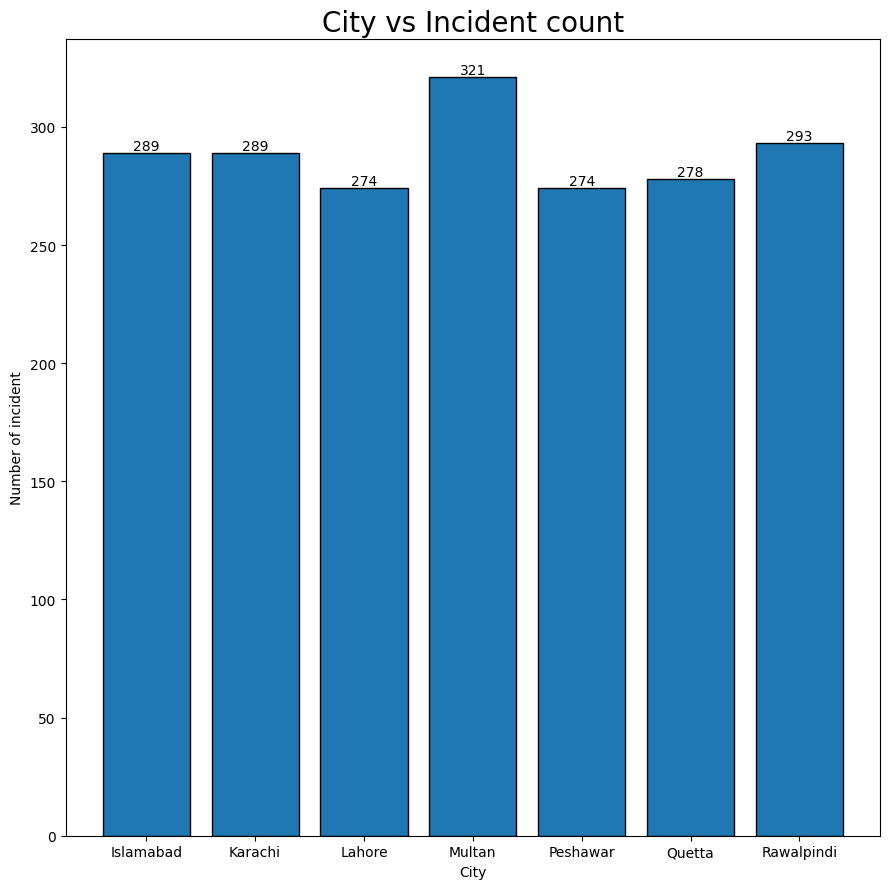

In [8]:
incident = df.groupby("City")["Incident"].sum()
plt.figure(figsize=(9,9))
bar = plt.bar(incident.index,incident.values,edgecolor = "Black")
plt.bar_label(bar)
plt.title("City vs Incident count",fontsize="20")
plt.xlabel("City")
plt.ylabel("Number of incident")
plt.tight_layout()
plt.savefig("city_VS_incident.png",dpi=300,bbox_inches="tight")
plt.show()


# City Vs Average Near miss Score

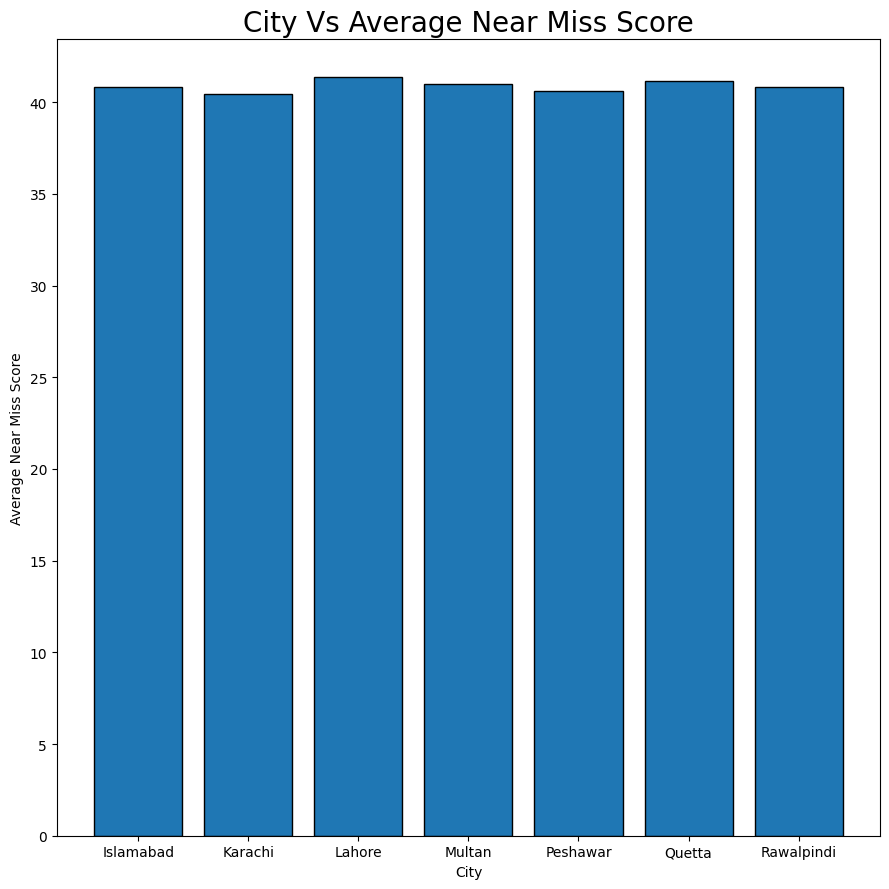

In [9]:
average_near_miss_score = df.groupby("City")["Near_Miss_Score"].mean()
plt.figure(figsize=(9,9))
plt.bar(average_near_miss_score.index,average_near_miss_score.values,edgecolor="Black")
plt.title("City Vs Average Near Miss Score",fontsize="20")
plt.xlabel("City")
plt.ylabel("Average Near Miss Score")
plt.tight_layout()
plt.savefig("City_VS_Avg_near_miss_score.png",dpi=300,bbox_inches="tight")
plt.show()

# Time Analysis

In [10]:
# which hour is the most incident ?
hour_most_incident = df.groupby("Hour")["Incident"].sum().idxmax()
print("houre most incident : ",hour_most_incident)

# which hour is the highest near miss score ?
high_near_miss_score = df.groupby("Hour")["Near_Miss_Score"].sum().idxmax()
print("\nhigh near miss score hour :",high_near_miss_score)

# which day has the most incident ?
most_incident_day = df.groupby("Day_of_Week")["Incident"].sum().idxmax()
print("\nDay on which most incident occured : ", most_incident_day)

# the most dangeorous houre ?
dangerous_hour = df.groupby("Hour")["Incident"].sum().idxmax()
print("\ndangerous_hour",dangerous_hour)


houre most incident :  11

high near miss score hour : 21

Day on which most incident occured :  Sunday

dangerous_hour 11


# Visualztion of the data 

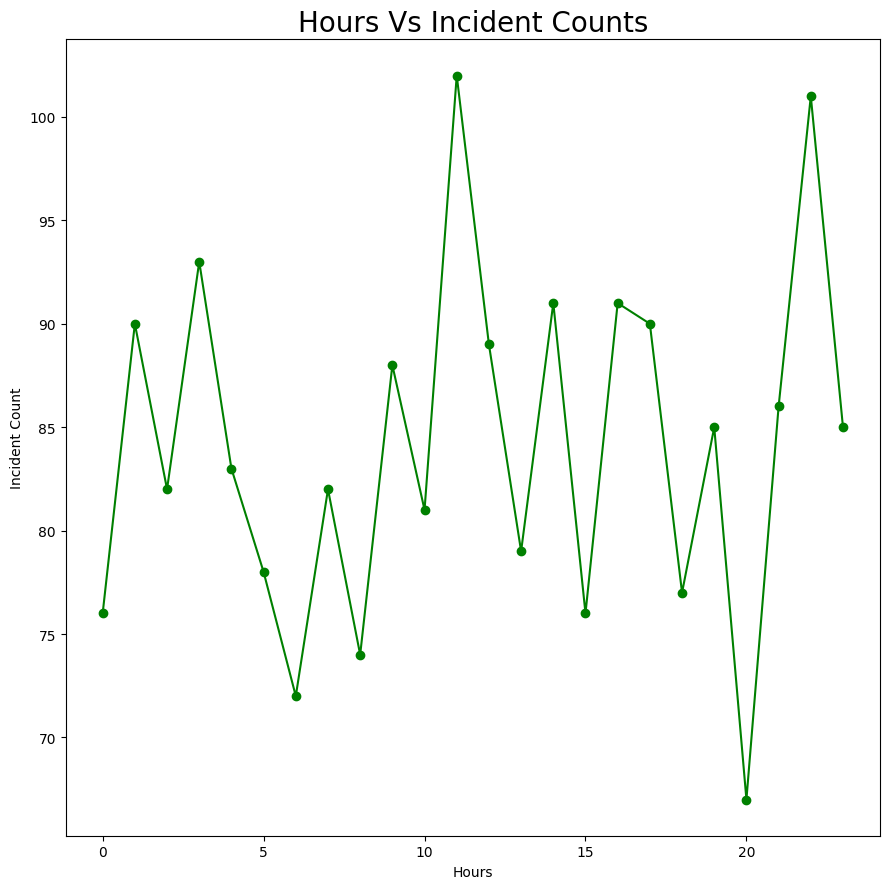

In [11]:
# hour vs incident count 
hour_incident_count = df.groupby("Hour")["Incident"].sum()
plt.figure(figsize=(9,9))
plt.plot(hour_incident_count,color="green",marker = "o")
plt.title("Hours Vs Incident Counts",fontsize = 20)
plt.xlabel("Hours")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.savefig("hour_Vs_Incident_count.png",dpi=300,bbox_inches="tight")
plt.show()

# Hours Vs Average Near miss score 

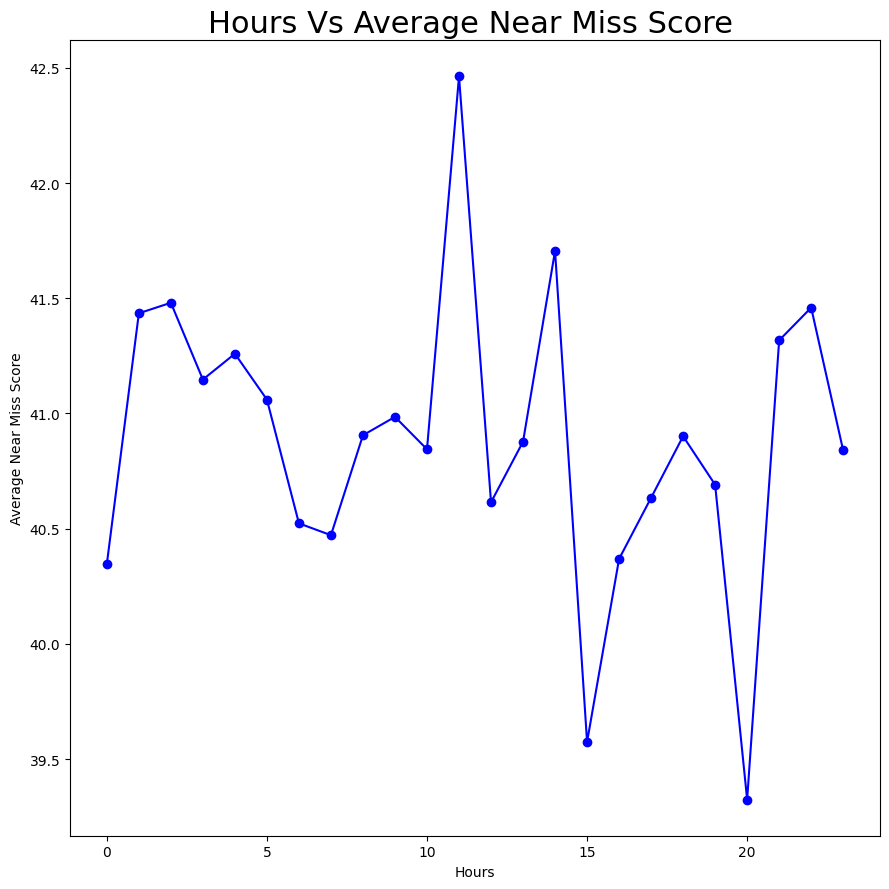

In [12]:
hour_vs_avg_miss_score = df.groupby("Hour")["Near_Miss_Score"].mean()
plt.figure(figsize=(9,9))
plt.plot(hour_vs_avg_miss_score,color="Blue",marker="o")
plt.title("Hours Vs Average Near Miss Score ",fontsize=22)
plt.xlabel("Hours")
plt.ylabel("Average Near Miss Score")
plt.tight_layout()
plt.savefig("hour_vs_avg_miss_score.png",dpi=300,bbox_inches="tight")
plt.show()


# wheather analysis

In [13]:
# how many observation occured in each wheather condition ?
wheather_cond = df["Weather"].value_counts()
print("wheather_cond : \n",wheather_cond)
print("__"*30)

# which weather condition has the most incident ?
most_incident = df.groupby("Weather")["Incident"].sum().idxmax()
print("\n\nWeather on which most incident occured : ",most_incident)
print("__"*30)


# which weather has the high most near miss score ?
weather_high_miss_score = df.groupby("Weather")["Near_Miss_Score"].mean().idxmax()
print("Weather high Near Miss Score : ",weather_high_miss_score)
print("__"*30)


# Does rain apper to incres risk ?
rain_appear = df["Weather"] == "Rain"
rain_appear_inc_risk = df.groupby(rain_appear)["Incident"].sum()
print("\n\nrain vs non rain risk observation :\n",rain_appear_inc_risk)
print("__"*30)


# Does fog appear to increse risk ?
fog_appear = df["Weather"] == "Fog"
fog_summary = df.groupby(fog_appear)["Incident"].sum()
print("\n\nwheater is fog : ",fog_summary)
print("__"*30)



# Compare average visability for each weather condition ?
compare_avg_vis = df.groupby("Weather")["Visibility_Percent"].mean()
print("\n\ncomparing average visiability of weather : ",compare_avg_vis)
print("__"*30)


wheather_cond : 
 Weather
Clear     5939
Cloudy    2403
Rain      1485
Dust      1199
Fog        974
Name: count, dtype: int64
____________________________________________________________


Weather on which most incident occured :  Clear
____________________________________________________________
Weather high Near Miss Score :  Fog
____________________________________________________________


rain vs non rain risk observation :
 Weather
False    1703
True      315
Name: Incident, dtype: int64
____________________________________________________________


wheater is fog :  Weather
False    1704
True      314
Name: Incident, dtype: int64
____________________________________________________________


comparing average visiability of weather :  Weather
Clear     89.698131
Cloudy    89.439534
Dust      65.116931
Fog       45.011191
Rain      78.338519
Name: Visibility_Percent, dtype: float64
____________________________________________________________


# Weather Vs Incident count 

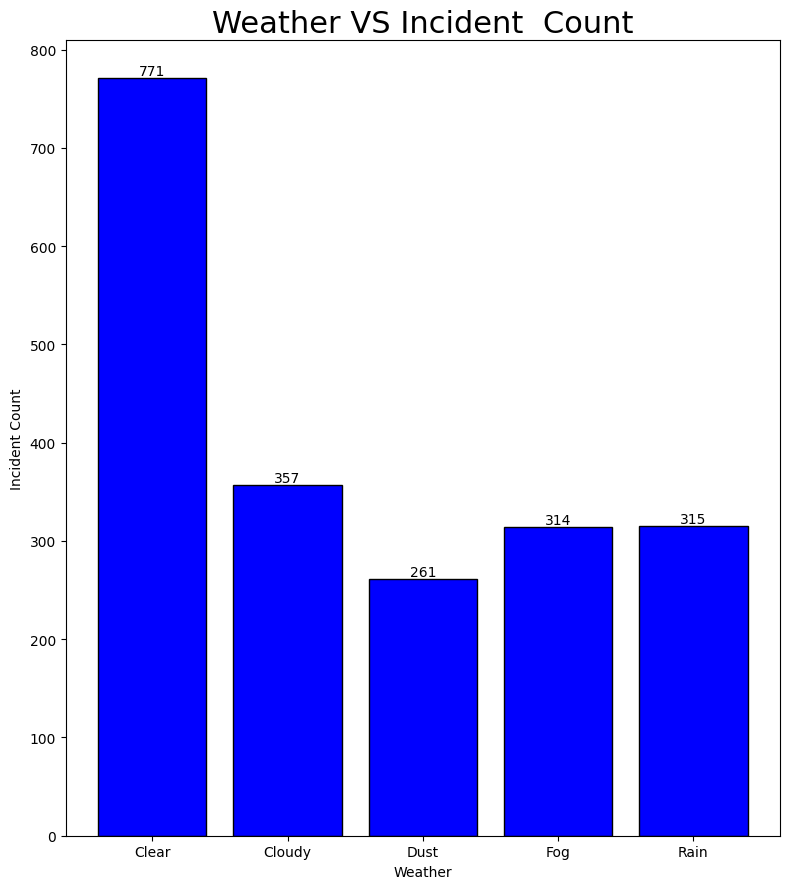

In [14]:
weather_Vs_incid_count = df.groupby("Weather")["Incident"].sum()
plt.figure(figsize=(8,9))
bar = plt.bar(weather_Vs_incid_count.index,weather_Vs_incid_count.values,color = "blue",edgecolor="Black")
plt.bar_label(bar)
plt.title("Weather VS Incident  Count",fontsize = 22)
plt.xlabel("Weather")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.savefig("weather_Vs_incid_count.png",dpi=300,bbox_inches = "tight")
plt.show()

# Traffic Analysis

In [15]:
df

,Record_ID,City,Day_of_Week,Hour,Weather,Traffic_Level,Vehicle_Type,Road_Type,Speed_Limit_kmh,Average_Speed_kmh,Pedestrian_Count,Visibility_Percent,Near_Miss_Score,Incident
0,1,Peshawar,Thursday,6,Cloudy,Medium,Motorcycle,Main Road,60,51.7,11,82.3,40.2,0
1,2,Karachi,Friday,19,Clear,Medium,Bus,Residential,50,51.8,10,91.1,31.6,0
2,3,Rawalpindi,Friday,14,Clear,Medium,Rickshaw,Residential,50,74.7,11,82.2,44.8,0
3,4,Peshawar,Sunday,10,Rain,High,Car,Main Road,60,39.4,7,74.0,35.6,0
4,5,Rawalpindi,Saturday,7,Rain,Severe,Rickshaw,Highway,100,62.5,8,97.3,57.1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,Quetta,Tuesday,19,Cloudy,Medium,Motorcycle,Market,50,37.3,31,74.5,37.9,0
11996,11997,Peshawar,Thursday,18,Rain,Severe,Rickshaw,Residential,50,22.7,10,84.4,76.3,1
11997,11998,Lahore,Sunday,13,Clear,Low,Van,Residential,50,41.7,8,98.3,20.8,0
11998,11999,Rawalpindi,Monday,1,Clear,Medium,Bus,Market,50,41.8,25,87.0,25.9,0


In [16]:


# how many possible categories ?
traffic_order =  ['Low', 'Medium', 'High', 'Severe']
df["Traffic_Level"] = pd.Categorical(df['Traffic_Level'],categories= traffic_order,ordered= True)

# how many belong to each traffic level ?
count = df["Traffic_Level"].value_counts().reindex(traffic_order)
print("\n",count)
print("__"*35)


# which traffic level has the most incident ?
traffic_level = df.groupby("Traffic_Level")["Incident"].sum()
most_incidentt = traffic_level.idxmax()
print("\ntraffic level most incident : ",most_incident)


# which traffic level has the highest average near miss score ?
avg_near_miss_score = df.groupby("Traffic_Level")["Near_Miss_Score"].mean()
avg_high_miss_Score = average_near_miss_score.idxmax()
print("Traffic Level has the highest average near miss score : ", avg_high_miss_Score)





 Traffic_Level
Low       2985
Medium    4250
High      3285
Severe    1480
Name: count, dtype: int64
______________________________________________________________________

traffic level most incident :  Clear
Traffic Level has the highest average near miss score :  Lahore


# Traffic level Vs Average Near Miss Score 

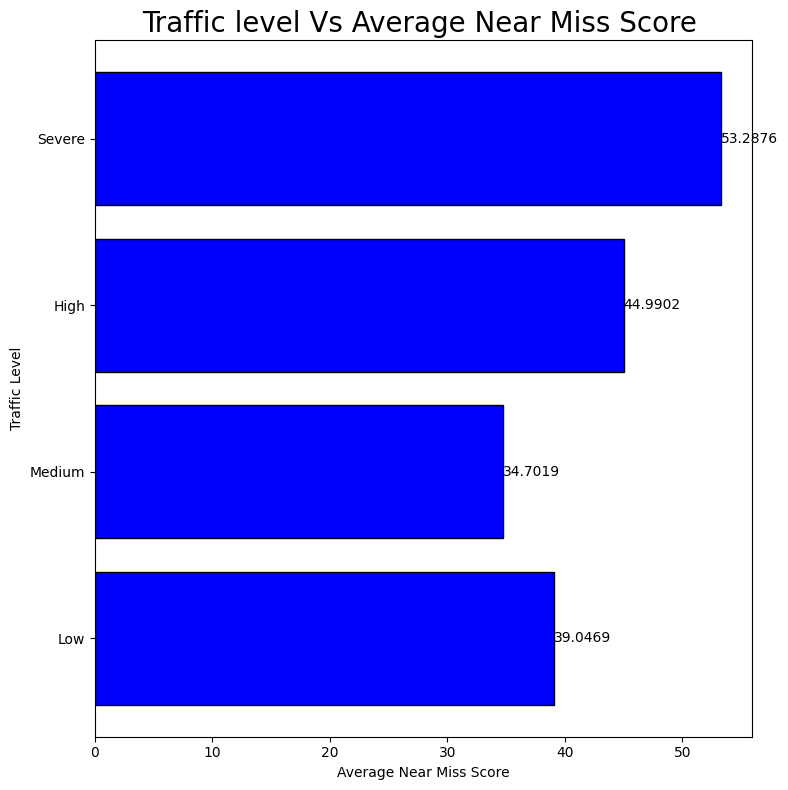

In [17]:
avg_miss_score = df.groupby("Traffic_Level")["Near_Miss_Score"].mean()
plt.figure(figsize=(8,8))
bar = plt.barh(avg_miss_score.index,avg_miss_score.values,color="blue",edgecolor="Black")
plt.bar_label(bar)
plt.title("Traffic level Vs Average Near Miss Score ",fontsize = 20)
plt.xlabel("Average Near Miss Score")
plt.ylabel("Traffic Level")
plt.tight_layout()
plt.savefig("Traffic_level_Vs_Average_Near_Miss_Score.png",dpi =300,bbox_inches = "tight")

plt.show()

# Vehicale Analysis

In [18]:
# vehicale type 
vehicale_type = ['Motorcycle', 'Bus','Rickshaw', 'Car']
df["Vehicle_Type"] = pd.Categorical(df["Vehicle_Type"],categories= vehicale_type,ordered = True)

countt_vehicle = df["Vehicle_Type"].value_counts().reindex(vehicale_type)
print(countt_vehicle)
print("__"*30)


# which vehicle type occure most often ?
most_occure_vehicle_type = countt_vehicle.idxmax()
print("\nmost occuring vehicle type : ",most_occure_vehicle_type)

# which vehicle type has the most incident ?
most_incident_vehicle = df.groupby("Vehicle_Type")["Incident"].idxmax()
print("most incident vehicle type : ",most_occure_vehicle_type)

# which vehicle type has the most highest average near miss score ?
vehicle_high_Near_miss_score = df.groupby("Vehicle_Type")["Near_Miss_Score"].mean().idxmax()
print("vehicle type highest Average Near Miss Score : \n",vehicle_high_Near_miss_score)
print("__"*30)

# calculate incident rate for each vehicle type ?
total = df.groupby("Vehicle_Type").size()
incidents = df.groupby("Vehicle_Type")["Incident"].sum()
incident_rate = (incidents / total) * 100
print("\nIncident rate each vehicle type : ",incident_rate)



Vehicle_Type
Motorcycle    4111
Bus            938
Rickshaw      2134
Car           3615
Name: count, dtype: int64
____________________________________________________________

most occuring vehicle type :  Motorcycle
most incident vehicle type :  Motorcycle
vehicle type highest Average Near Miss Score : 
 Motorcycle
____________________________________________________________

Incident rate each vehicle type :  Vehicle_Type
Motorcycle    23.060083
Bus           12.579957
Rickshaw      14.339269
Car           13.997234
dtype: float64


/tmp/ipykernel_10701/133102198.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df["Vehicle_Type"] = pd.Categorical(df["Vehicle_Type"],categories= vehicale_type,ordered = True)


# Vehicle Type vs Incident Count

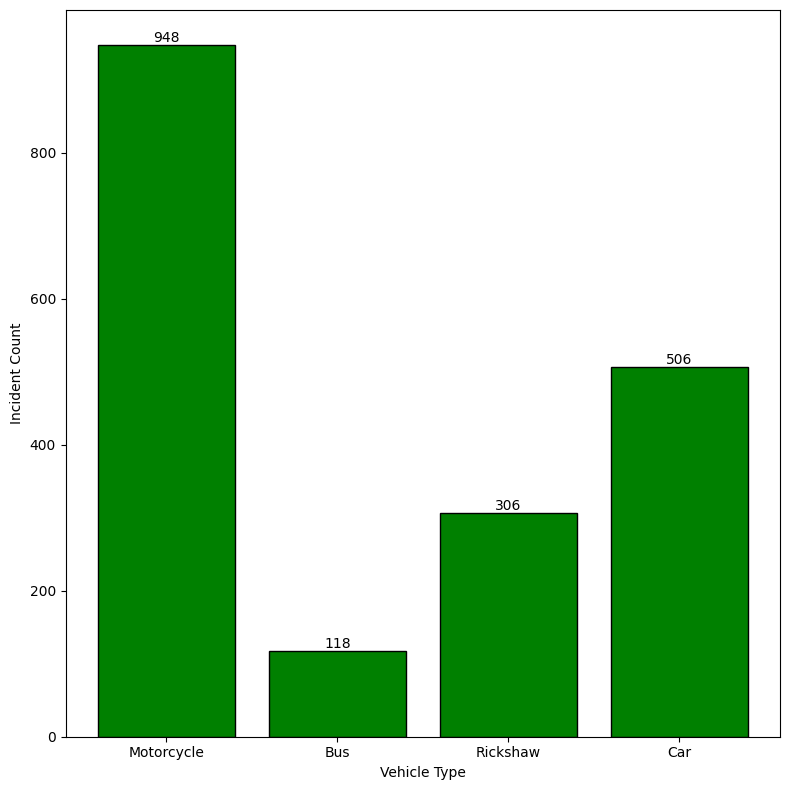

In [19]:
count_incident_veh_type = df.groupby("Vehicle_Type")["Incident"].sum()
plt.figure(figsize=(8,8))
bar = plt.bar(count_incident_veh_type.index,count_incident_veh_type.values,color="Green",edgecolor="Black")
plt.bar_label(bar)
plt.xlabel("Vehicle Type")
plt.ylabel("Incident Count")
plt.tight_layout()
plt.savefig("vehicale_type_VS_incident.png",dpi=300,bbox_inches = "tight")
plt.show()

# Speed analysis

In [20]:
# compare speed limit ,average speed , near miss score  and incident 
comp_speed = df.groupby("Speed_Limit_kmh")[['Average_Speed_kmh','Near_Miss_Score','Incident']].mean()
print(comp_speed)
print("__"*35)

# create a new columns speed diffrence 
df["Speed_diffrenece"] = df["Average_Speed_kmh"] - df["Speed_Limit_kmh"]


# which trips exceeds the speed limit ?
trips_exceeds = df[df['Average_Speed_kmh'] > df['Speed_Limit_kmh']][["Record_ID", "City", "Vehicle_Type", "Speed_Limit_kmh", "Average_Speed_kmh"]]
print("\n",trips_exceeds)
print("__"*35)

# how many exceeds the speed limit ?
count =(df["Average_Speed_kmh"] > df["Speed_Limit_kmh"]).sum()
print("\ncounts exceeds the speed limit : ",count)

# Find speeding observations
speeding = df["Average_Speed_kmh"] > df["Speed_Limit_kmh"]

# Calculate average Near Miss Score
average_near_miss_score_speeding = df.loc[speeding,"Near_Miss_Score"].mean()

print(average_near_miss_score_speeding)

                 Average_Speed_kmh  Near_Miss_Score  Incident
Speed_Limit_kmh                                              
40                       28.166893        49.891502  0.293678
50                       37.227447        39.334681  0.147234
60                       47.296028        39.402388  0.149013
100                      86.460142        40.796813  0.161861
______________________________________________________________________

        Record_ID        City Vehicle_Type  Speed_Limit_kmh  Average_Speed_kmh
1              2     Karachi          Bus               50               51.8
2              3  Rawalpindi     Rickshaw               50               74.7
8              9  Rawalpindi          NaN               60               65.4
9             10      Multan          Car              100              106.1
18            19      Quetta          NaN               50               53.6
...          ...         ...          ...              ...                ...
11983    

In [21]:
df

,Record_ID,City,Day_of_Week,Hour,Weather,Traffic_Level,Vehicle_Type,Road_Type,Speed_Limit_kmh,Average_Speed_kmh,Pedestrian_Count,Visibility_Percent,Near_Miss_Score,Incident,Speed_diffrenece
0,1,Peshawar,Thursday,6,Cloudy,Medium,Motorcycle,Main Road,60,51.7,11,82.3,40.2,0,-8.3
1,2,Karachi,Friday,19,Clear,Medium,Bus,Residential,50,51.8,10,91.1,31.6,0,1.8
2,3,Rawalpindi,Friday,14,Clear,Medium,Rickshaw,Residential,50,74.7,11,82.2,44.8,0,24.7
3,4,Peshawar,Sunday,10,Rain,High,Car,Main Road,60,39.4,7,74.0,35.6,0,-20.6
4,5,Rawalpindi,Saturday,7,Rain,Severe,Rickshaw,Highway,100,62.5,8,97.3,57.1,1,-37.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,Quetta,Tuesday,19,Cloudy,Medium,Motorcycle,Market,50,37.3,31,74.5,37.9,0,-12.7
11996,11997,Peshawar,Thursday,18,Rain,Severe,Rickshaw,Residential,50,22.7,10,84.4,76.3,1,-27.3
11997,11998,Lahore,Sunday,13,Clear,Low,NaN,Residential,50,41.7,8,98.3,20.8,0,-8.3
11998,11999,Rawalpindi,Monday,1,Clear,Medium,Bus,Market,50,41.8,25,87.0,25.9,0,-8.2


# Pedistrian Analysis

In [50]:
# what is the average pedestrian count ?
average_pedestrian = df["Pedestrian_Count"].mean()
print("Average Pedestrian Count : ",average_pedestrian.round(3))
print("__"*30)

# which road type has the most pedestrian count ?
most_pedes_road = df.groupby("Road_Type")["Pedestrian_Count"].mean().sort_values(ascending=False)
print("\nRoad type has the most Pedestrian Count\n",most_pedes_road)
print("__"*30)


# Does higher pedestrian count corresponds to higher  a near miss score ?
corresponds = df["Pedestrian_Count"].corr(df["Near_Miss_Score"])
print("\npedestrian count correlation with near miss score : ",corresponds)

# compare incidents when pedestrian count is high or low ?
median_count = df['Pedestrian_Count'].median()
df["Pedestrian_Level"] = df["Pedestrian_Count"].apply(lambda x : "high" if x > median_count else "low")
print("__"*30)

incident_Rate = df.groupby("Pedestrian_Level")["Incident"].mean()
print("incident rate by Pedestrian Level :\n", incident_Rate)



Average Pedestrian Count :  13.757
____________________________________________________________

Road type has the most Pedestrian Count
 Road_Type
School Zone    35.037390
Market         22.068684
Residential     8.068373
Highway         8.017198
Main Road       7.951194
Name: Pedestrian_Count, dtype: float64
____________________________________________________________

pedestrian count correlation with near miss score :  0.19871074223074545
____________________________________________________________
incident rate by Pedestrian Level :
 Pedestrian_Level
high    0.186703
low     0.150351
Name: Incident, dtype: float64


# Pedestrian Count Vs Near Miss Score Scatter Plot

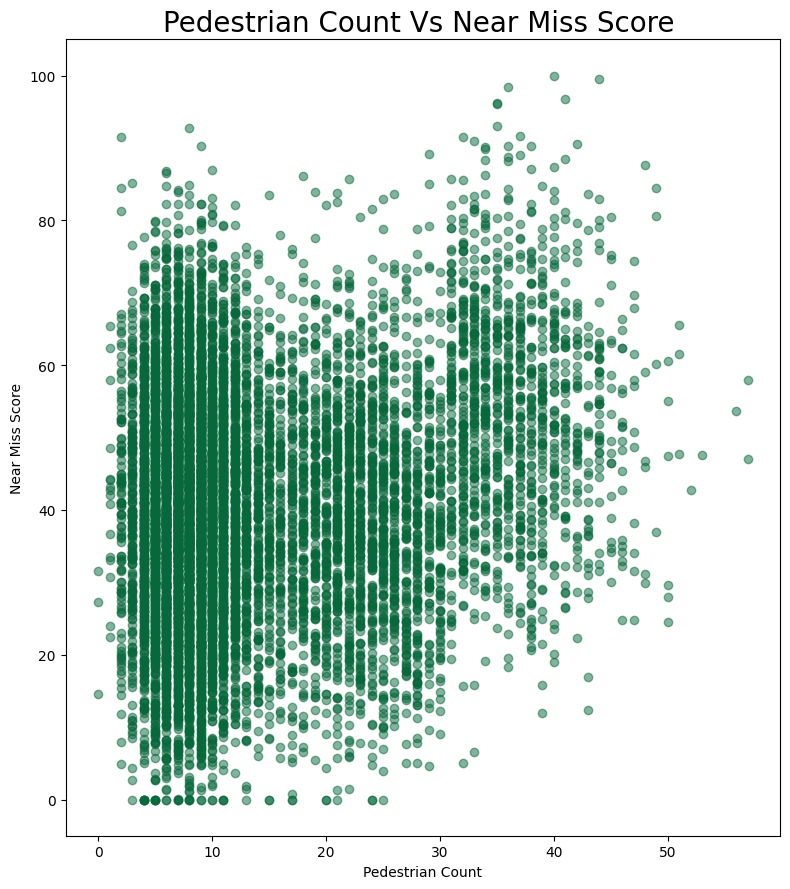

In [57]:
plt.figure(figsize=(8,9))
plt.scatter(df["Pedestrian_Count"],df["Near_Miss_Score"],alpha=0.5, color="#07683B")
plt.title("Pedestrian Count Vs Near Miss Score ",fontsize = 20)
plt.xlabel("Pedestrian Count")
plt.ylabel("Near Miss Score")
plt.tight_layout()
plt.savefig("Pedestrian_Count_Vs_Near_Miss_Score.png",dpi=300,bbox_inches= "tight")
plt.show()

# Insights
* Average speed is 47 km.
* highest speed is 120 km.
* total observation is 12000.
* total incident observation is 2018 .
* the highest observation city is karchi.
* most incident occured in multan .
* less incident occred in peshawar .
* on the sunday most incident are occured .
